In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_rms(data):
	data = np.array(data)
	data = data - (sum(data)/len(data))
	s = data**2
	ms = sum(s)/len(s)
	rms = np.sqrt(ms)
	return rms

def avg_peak_height(data):
	# Extract peak heights
	y = []
	x = []
	for i in range(len(data) - 5):
		if data[i] >= max(data[i+1], data[i+2], data[i-1], data[i-2]):
			y.append(data[i])
			x.append(i)
	return sum(y)/len(y)

In [3]:
a = np.arange(1, 10, 1)
datas = {}
for i in a:
	data = np.loadtxt(rf"C:\\Users\\BaughLaflamme\\Desktop\\Qblox Master Folder\\Cluster\\Testing\\Tests\\Output linearity tests\\QRM_QRM\\data\\out1_in0_amp0_{i}.txt")
	datas[round(i/10, 1)] = data[300:15000]
datas[1.0] = np.loadtxt(rf"C:\\Users\\BaughLaflamme\\Desktop\\Qblox Master Folder\\Cluster\\Testing\\Tests\\Output linearity tests\\QRM_QRM\\data\\out1_in0_amp1.txt")[300:15000]

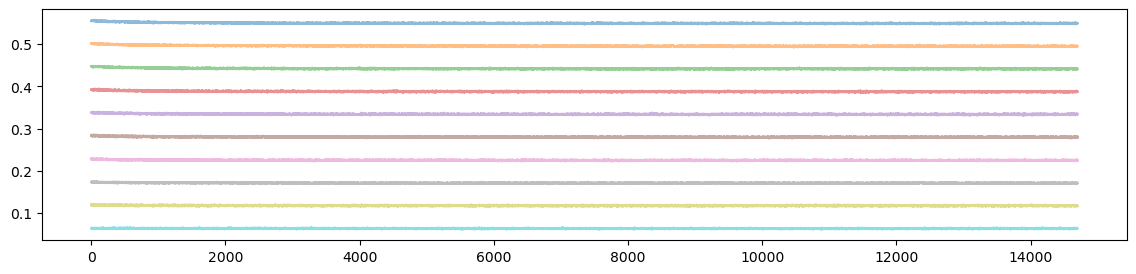

In [4]:
fig, ax = plt.subplots(1, 1, figsize= (14, 3))
b = reversed(np.arange(0.1, 1, 0.1))
rmss = []
avg_peaks = []
ax.plot(datas[1.0], alpha = 0.5)
rmss.append(get_rms(datas[1.0]))
avg_peaks.append(sum(datas[1.0])/len(datas[1.0]))
for i in b:
	avg_peaks.append(sum(datas[round(i, 1)])/len(datas[round(i, 1)]))
	ax.plot(datas[round(i, 1)], alpha = 0.5)
plt.show()
amps = np.array([1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1])

In [5]:
amps_0 = np.append(np.array([0]), amps)

fit_peak = np.polyfit(amps, avg_peaks, 1)
yl_peak = fit_peak[0]*amps_0 + fit_peak[1]

quad_peak = np.polyfit(amps, avg_peaks, 2)
yq_peak = quad_peak[0]*(amps_0**2) + quad_peak[1]*amps_0 + quad_peak[2]

In [6]:
# Getting R**2 value for each fit
def r_squared(data, fit):
	mean = sum(data) / len(data)
	sstot = sum((data-mean)**2)
	ssres = sum((data - fit)**2)
	return 1 - (ssres/sstot)

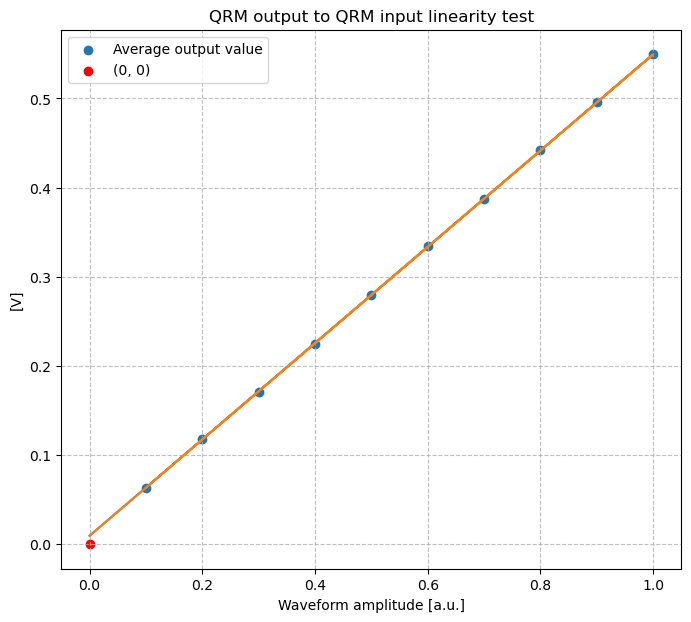

Peak linear fit R**2:    1.0
Peak quadratic fit R**2: 1.0



In [7]:
fig, ax = plt.subplots(1, 1, figsize = (8, 7))
ax.scatter(amps, avg_peaks, label = "Average output value")
ax.grid(ls = "--", alpha = 0.8)
ax.plot(amps_0, yl_peak)
ax.plot(amps_0, yq_peak)
ax.scatter(0, 0, color = "r", label = "(0, 0)")
ax.set_ylabel("[V]")
ax.set_xlabel("Waveform amplitude [a.u.]")
ax.set_title("QRM output to QRM input linearity test")
plt.legend()
plt.show()

print("Peak linear fit R**2:    {:.3}\n".format(r_squared(avg_peaks, yl_peak[1:])) +
	  "Peak quadratic fit R**2: {:.4}\n".format(r_squared(avg_peaks, yq_peak[1:])))